In [1]:
import pandas as pd
from sqlalchemy import create_engine

import sys
sys.path.append('../..')
from final_project.scripts.data_analysis_utils import setup_categorical_type

import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

In [2]:
engine = create_engine('sqlite:///../data/database.db')

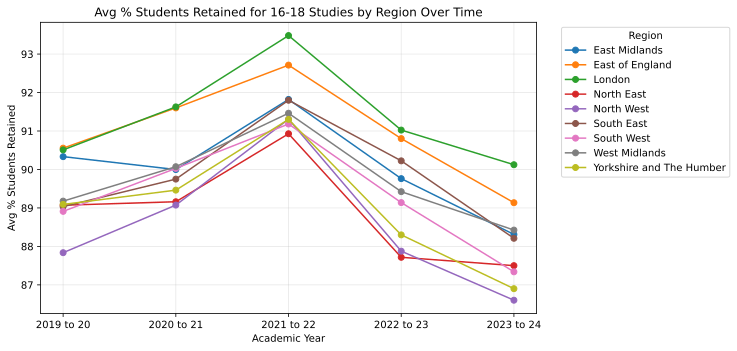

In [3]:
query = """
SELECT time_period, region, AVG(perc_retained) AS avg_perc_retained
FROM retention
GROUP BY region, time_period
ORDER BY time_period, region
"""
pd.read_sql(query, engine)

perc_retained_df = pd.read_sql(query, engine)
pivot_df = perc_retained_df.pivot(index="time_period", columns="region", values="avg_perc_retained")


plt.figure(figsize=(11, 5))
plt.plot(pivot_df, marker="o", label=pivot_df.columns)

plt.xlabel("Academic Year")
plt.ylabel("Avg % Students Retained")
plt.title("Avg % Students Retained for 16-18 Studies by Region Over Time")

plt.grid(True, alpha=0.3)
plt.legend(title="Region", bbox_to_anchor=(1.4, 1), loc="upper right")

plt.tight_layout()
plt.show()

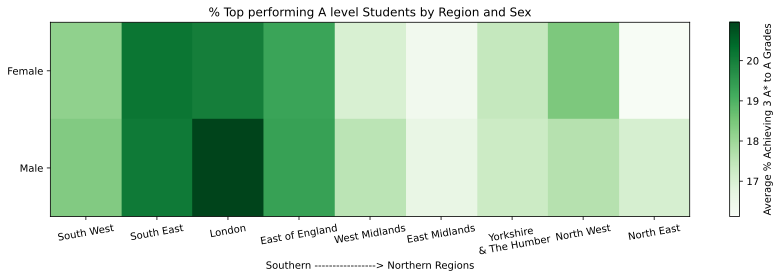

In [6]:
query = """
SELECT
    region,
    characteristic_value AS sex,
    AVG(perc_achieving_3_astar_to_a_grades) AS avg_perc_achieving_top_grades
FROM characteristics
WHERE characteristic_type = 'Sex'
GROUP BY region, characteristic_value
"""
heatmap_df = pd.read_sql(query, engine)

pivot_heatmap = heatmap_df.pivot(index="sex", columns="region", values="avg_perc_achieving_top_grades")
rearranged_df = pivot_heatmap[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                               "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df.rename(columns={"Yorkshire and The Humber": "Yorkshire\n & The Humber"}, inplace=True)

plt.figure(figsize=(12, 4))

plt.imshow(rearranged_df, cmap='Greens', aspect='auto')
plt.colorbar(label="Average % Achieving 3 A* to A Grades")

plt.xticks(ticks=range(len(rearranged_df.columns)), labels=rearranged_df.columns, rotation=10)
plt.yticks(ticks=range(len(rearranged_df.index)), labels=rearranged_df.index)
plt.title("% Top performing A level Students by Region and Sex")
plt.xlabel("Southern -----------------> Northern Regions")

plt.tight_layout()
plt.show()

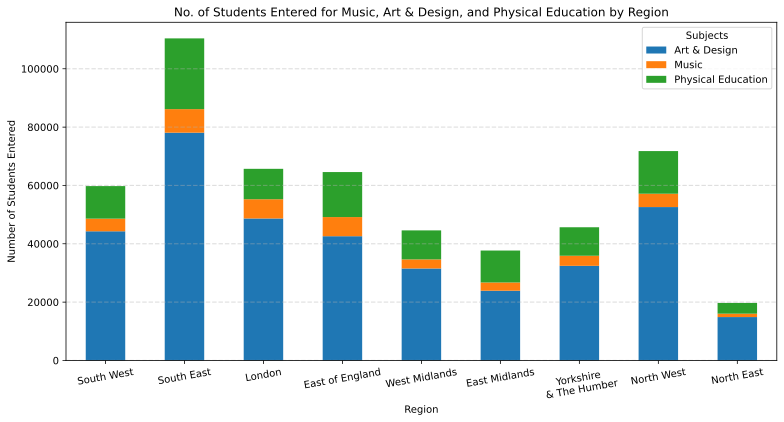

In [8]:
query = """
SELECT
    region,
    subject_area AS subject,
    SUM(number_of_students_entered) AS total_students_entered
FROM results
WHERE subject = 'Music' OR subject = 'Art & Design' OR subject = 'Physical Education'
GROUP BY region, subject
"""
subject_df = pd.read_sql(query, engine)

pivot_subject_df = subject_df.pivot(index="subject", columns="region", values="total_students_entered")
rearranged_df = pivot_subject_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

rearranged_df.plot(
    kind='bar',
    stacked=True,
    figsize=(11, 6)
)

plt.ylabel("Number of Students Entered")
plt.xlabel("Region")
plt.title("No. of Students Entered for Music, Art & Design, and Physical Education by Region")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Subjects", loc="upper right")

plt.tight_layout()
plt.show()

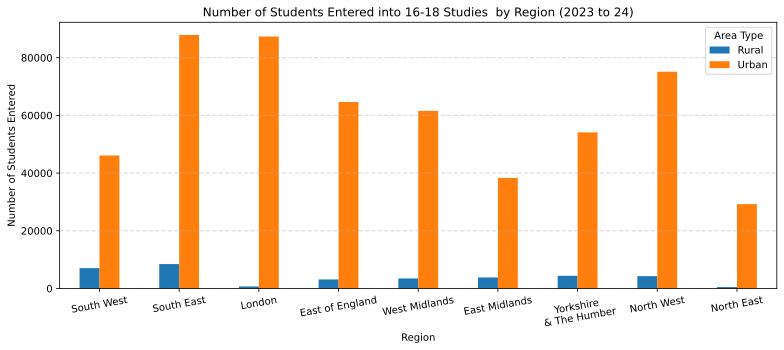

In [9]:
query = """
SELECT
    region,
    CASE
        WHEN rurality LIKE '%Rural%' THEN 'Rural'
        WHEN rurality LIKE '%Urban%' THEN 'Urban'
    END AS rurality_type,
    SUM(number_of_students_completed) AS total_students
FROM rurality
WHERE time_period = '2023 to 24'
GROUP BY region, rurality_type
ORDER BY region, rurality_type
"""
rurality_comp_df = pd.read_sql(query, engine)

pivot_rurality = rurality_comp_df.pivot(index="rurality_type", columns="region", values="total_students")
rearranged_df = pivot_rurality[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

rearranged_df.plot(
    kind='bar',
    stacked=False,
    figsize=(11, 5)
)

plt.ylabel("Number of Students Entered")
plt.xlabel("Region")
plt.title("Number of Students Entered into 16-18 Studies  by Region (2023 to 24)")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', linewidth=1.2, alpha=0.4)
plt.legend(title="Area Type", loc="upper right")

plt.tight_layout()
plt.show()


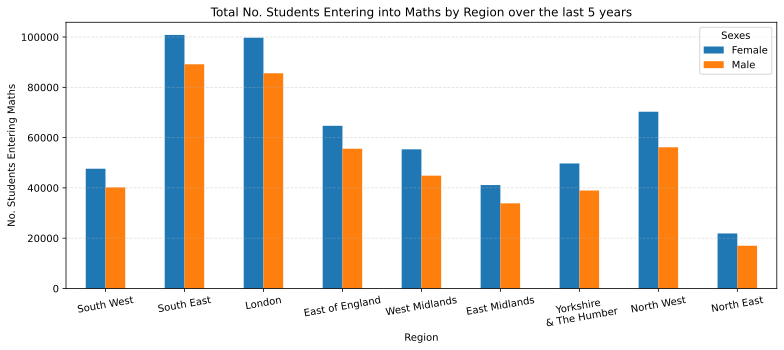

In [31]:
query = """
SELECT
    region,
    sex,
    SUM(number_of_students_entered) AS avg_entered
FROM stem
WHERE sex IN ('Male', 'Female')
    AND subject_combination LIKE '%math%'
GROUP BY region, sex
"""
stem_df = pd.read_sql(query, engine)

pivot_stem_df = stem_df.pivot(index="sex", columns="region", values="avg_entered")
rearranged_df = pivot_stem_df[["South West", "South East", "London", "East of England", "West Midlands", "East Midlands",
                                  "Yorkshire and The Humber", "North West", "North East"]]
rearranged_df = rearranged_df.T.rename(index={"Yorkshire and The Humber": "Yorkshire\n & The Humber"})

rearranged_df.plot(
    kind='bar',
    stacked=False,
    figsize=(11, 5)
)

plt.ylabel("No. Students Entering Maths")
plt.xlabel("Region")
plt.title("Total No. Students Entering into Maths by Region over the last 5 years")
plt.xticks(rotation=10)

plt.grid(axis="y", linestyle='--', alpha=0.4)
plt.legend(title="Sexes", loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
rurality_df["dropout_rate"] = (rurality_df["number_of_students_entered"] - 
                               rurality_df["number_of_students_potential"])/ rurality_df["number_of_students_entered"]

In [ ]:
chars_df.groupby("region_name").apply(lambda x: x.isnull().sum(), include_groups=False)

In [ ]:
chars_df[chars_df["number_of_students_potential"].isnull()]

In [ ]:
chars_df["characteristic_type"].unique()

In [ ]:
engine.dispose()